# Auto Insurance Pricing Model

This project predicts **pure premium pricing model** for auto insurance using real French motor claims data. The data originates from HuggingFace interface and is available at: https://huggingface.co/datasets/mabilton/fremtpl2/tree/refs%2Fconvert%2Fparquet

The core idea is simple: to price a policy fairly, we want to estimate how much a given customer is *expected* to cost us per year. We do this in two steps:

1. **Frequency model** – How likely is this customer to make a claim?
2. **Severity model** – If they do make a claim, how large will it be?

Multiply those two together and you get the **pure premium** – the baseline amount we need to charge just to break even (before expenses or profit loading).

---

### The Data
- **freMTPL2freq** – One row per policy, with claim counts and policyholder characteristics
- **freMTPL2sev** – One row per claim, with the claim amount

Key variables used to model and predict the pure premium are mentioned below:
| Feature | Description |
|---|---|
| `ClaimNb` | Number of claims the policy made |
| `Exposure` | Fraction of year the policy was active |
| `DrivAge` | Age of the driver |
| `VehAge` | Age of the vehicle |
| `VehPower` | Engine power of the vehicle |
| `BonusMalus` | Claims history score (100 = clean, higher = worse record) |
| `Area` | Urban density of where the driver lives (A=rural, F=very urban) |
| `VehBrand` | Vehicle brand category |
| `VehGas` | Fuel type (Regular or Diesel) |
| `Region` | French administrative region |

In [75]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

BLUE   = '#2563EB'
ORANGE = '#F97316'
GREEN  = '#16A34A'
RED    = '#DC2626'
GRAY   = '#6B7280'

## Step 1: Load & Prepare the Data

We load the csv files and prepare the dataset for merging.

In [2]:
# Get project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load data
freq = pd.read_csv(os.path.join(project_root, "data", "freMTPL2freq.csv"))
sev = pd.read_csv(os.path.join(project_root, "data", "freMTPL2sev.csv"))

In [17]:
freq.head()
sev.head()

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


In [19]:
# Merging by left join to ensure that all policy rows are kept
df = freq.merge(sev, on="IDpol", how="left")

It is completely normal for ClaimAmount to have a lot of NaNs after the merge because the severity dataset only contains policy records with at least one claim.

In [21]:
# Replacing all Nans with 0 to ensure a better fit for modeling later
df["ClaimAmount"] = df["ClaimAmount"].fillna(0)

Since `Severity` is the average claim amount per claim, we are dividing total `claimAmount` with number of claims, `ClaimNb`, to find an average. Understandably policies with no claims will have no severity.

In [22]:
df["Severity"] = np.where(
    df["ClaimNb"] > 0,
    df["ClaimAmount"] / df["ClaimNb"],
    0
)

Below we use `log(Exposure)` as an offset in our frequency model for two reasons:

1. **Rate modeling**: We want to predict claims *per year*, not total claims. 
   The offset ensures the model understands that a policy with 0.5 years exposure 
   should have half the expected claims of a full-year policy.

2. **Poisson link function**: With a log link, `log(Expected Claims) = log(Exposure) + Xβ`
   makes `Expected Claims = Exposure × exp(Xβ)`, which is exactly what we want.

We treat it as built-in exposure weighting where the model automatically scales predictions 
by how long each policy was observed.

In [24]:
# Log-exposure offset for the frequency model
df["logExposure"] = np.log(df["Exposure"])

print(f"Total policies: {len(df):,}")
print(f"Policies with at least one claim: {(df['ClaimNb'] > 0).sum():,} ({(df['ClaimNb'] > 0).mean():.1%})")
print(f"Average claim amount (among claimants): £{df.loc[df['ClaimNb']>0, 'ClaimAmount'].mean():,.0f}")
df.head()

Total policies: 679,513
Policies with at least one claim: 35,560 (5.2%)
Average claim amount (among claimants): £1,685


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount,Severity,logExposure
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0,-2.302585
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0,-0.261365
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,0.0,-0.287682
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0,-2.407946
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0,-0.174353


# EDA

To ensure we catch correlations that need to be examined within our features, we produce a heatmap below so we could include interaction terms later if needed.

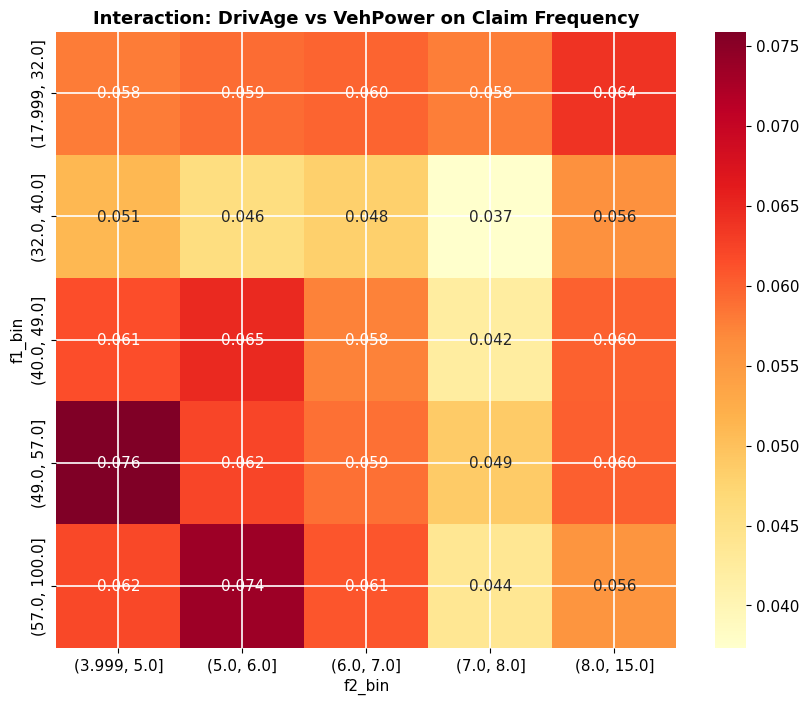

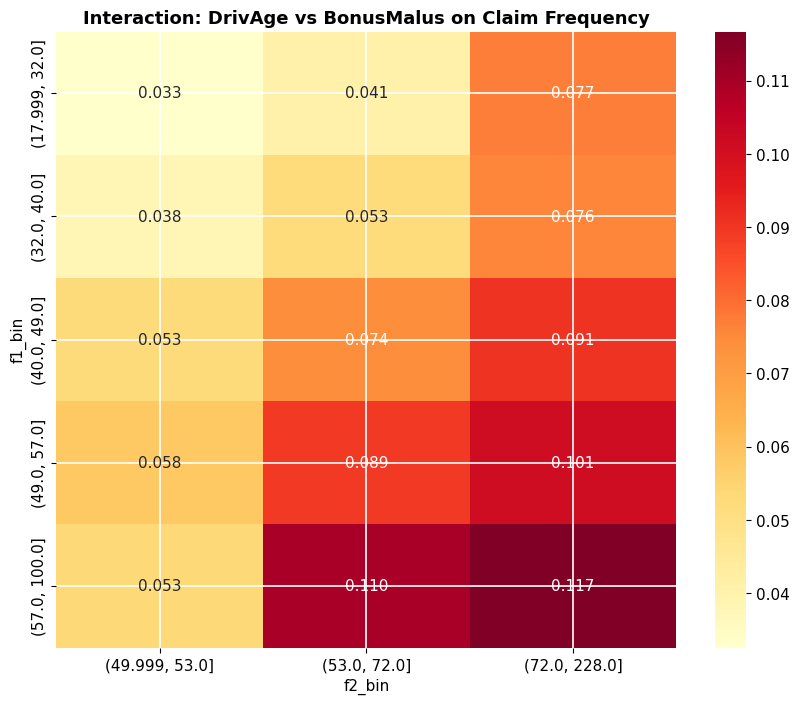

In [76]:
# Method 1: Two-way ANOVA style plots
# Create a function to visualize interactions
def plot_interaction(df, feat1, feat2, target='ClaimNb'):
    # Create bins for both features
    df['f1_bin'] = pd.qcut(df[feat1], q=5, duplicates='drop')
    df['f2_bin'] = pd.qcut(df[feat2], q=5, duplicates='drop')
    
    # Pivot table of average claim frequency
    pivot = df.pivot_table(values=target, 
                           index='f1_bin', 
                           columns='f2_bin', 
                           aggfunc='mean')
    
    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
    plt.title(f'Interaction: {feat1} vs {feat2} on Claim Frequency')
    plt.show()

# Check a few promising interactions
plot_interaction(train_df, 'DrivAge', 'VehPower')
plot_interaction(train_df, 'DrivAge', 'BonusMalus')

The plots above suggest minimal correlation amongst our features. Hence, we decide to keep a simple GLM going forward.

## Step 2: Train / Test Split

Before fitting any models, we set aside **20% of the data as a test set**. The purpose of this split is to later calibrate how our model is performing against the set-out new, unseen policyholder data, as a metric for model fit and accuracy.


In [27]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training set: {len(train_df):,} policies")
print(f"Test set:     {len(test_df):,} policies")

# Severity subsets (only claimants)
train_sev = train_df[train_df["ClaimNb"] > 0].copy()
test_sev  = test_df[test_df["ClaimNb"] > 0].copy()

Training set: 543,610 policies
Test set:     135,903 policies


## Step 3: Frequency Model (How Often Do Claims Happen?)

We use a **Poisson GLM** due to the nature of the claims resembling count data. We keep a log-offset for exposure so the model accounts for policies that were only active for part of the year.

In [46]:
freq_formula = (
    "ClaimNb ~ DrivAge + VehAge + BonusMalus + C(Area) "
    "+ VehPower + C(VehBrand) + C(VehGas) + C(Region)"
)

freq_model = smf.glm(
    formula=freq_formula,
    data=train_df,
    family=sm.families.Poisson(),
    offset=train_df["logExposure"]
).fit()

print(freq_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               543610
Model:                            GLM   Df Residuals:                   543569
Model Family:                 Poisson   Df Model:                           40
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2506e+05
Date:                Wed, 04 Mar 2026   Deviance:                   1.9113e+05
Time:                        04:59:33   Pearson chi2:                 1.81e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01261
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

To assess the model fit, we perform some diagnostic tests below. The p-values of our features are mostly oscillating around 0.002 which suggest significance of terms.

Dispersion parameter: 3.323
⚠️ Evidence of overdispersion - consider Negative Binomial


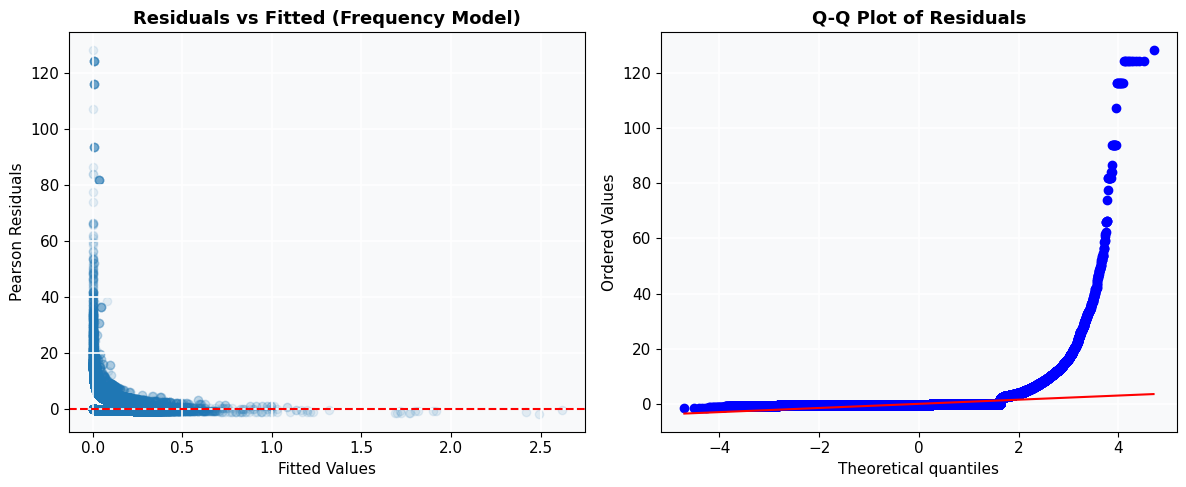

In [77]:
# After fitting freq_model, add diagnostic cells:

# Check for overdispersion
# For Poisson, variance should ≈ mean
pearson_chi2 = freq_model.pearson_chi2
df_resid = freq_model.df_resid
dispersion = pearson_chi2 / df_resid
print(f"Dispersion parameter: {dispersion:.3f}")
if dispersion > 1.2:
    print("⚠️ Evidence of overdispersion - consider Negative Binomial")

# Residual plot
fitted_vals = freq_model.fittedvalues
residuals = freq_model.resid_pearson

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(fitted_vals, residuals, alpha=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Pearson Residuals')
plt.title('Residuals vs Fitted (Frequency Model)')

# Q-Q plot
plt.subplot(1, 2, 2)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

The diagnostic plots above demonstrate that our model violates the Poisson model assumption of **equidispersion**, whereby the mean is equal to the variance. In insurance data, we often see **overdispersion** where variance > mean due to:

1. **Unobserved heterogeneity**: Policyholders within the same rating cell have 
   different underlying risk levels
2. **Contagion effects**: One claim might increase the probability of another
3. **Clustering**: Claims may cluster in time or space

Since our model produces a dispersion parameter of 3.323, it means that our data has 3.323 times more variance than Poisson assumes. This leads to small standard errors, suggesting over significance of variables and overconfident forecasts. 

In lieu of that, we try a Negative Binomial approach below:

In [ ]:
# After your Poisson model, add Negative Binomial
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Fit Negative Binomial model (using same formula)
nb_model = smf.glm(
    formula=freq_formula,
    data=train_df,
    family=sm.families.NegativeBinomial(),  
    offset=train_df["logExposure"]
).fit()

print("="*80)
print("NEGATIVE BINOMIAL MODEL RESULTS")
print("="*80)
print(nb_model.summary())

# Compare dispersion parameters
print(f"\nPoisson Dispersion: {freq_model.pearson_chi2 / freq_model.df_resid:.4f}")
print(f"Negative Binomial Dispersion: {nb_model.pearson_chi2 / nb_model.df_resid:.4f}")


NEGATIVE BINOMIAL MODEL RESULTS
                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               543610
Model:                            GLM   Df Residuals:                   543569
Model Family:        NegativeBinomial   Df Model:                           40
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2322e+05
Date:                Wed, 04 Mar 2026   Deviance:                   1.6406e+05
Time:                        10:02:20   Pearson chi2:                 1.73e+06
No. Iterations:                     8   Pseudo R-squ. (CS):            0.01174
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

Our dispersion parameter lowers for the Negative Binomial model. However, before we move on, we must leverage other metrics to test predictive performance of each approach.

In [80]:
# Compare predictive performance
test_df = test_df.copy()
test_df["PredFreq_Poisson"] = freq_model.predict(test_df, offset=test_df["logExposure"])
test_df["PredFreq_NB"] = nb_model.predict(test_df, offset=test_df["logExposure"])

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

metrics = pd.DataFrame({
    'Model': ['Poisson', 'Negative Binomial'],
    'MAE': [
        mean_absolute_error(test_df['ClaimNb'], test_df['PredFreq_Poisson']),
        mean_absolute_error(test_df['ClaimNb'], test_df['PredFreq_NB'])
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(test_df['ClaimNb'], test_df['PredFreq_Poisson'])),
        np.sqrt(mean_squared_error(test_df['ClaimNb'], test_df['PredFreq_NB']))
    ]
})

print("\nFrequency Model Performance on Test Set:")
print(metrics.to_string(index=False))


Frequency Model Performance on Test Set:
            Model      MAE     RMSE
          Poisson 0.107693 0.284367
Negative Binomial 0.108391 0.284488


The diagnostic plots suggested possible overdispersion, prompting us to test a 
Negative Binomial alternative. However, the out-of-sample performance tells a 
different story:

**Key Findings:**
- Both models achieve nearly identical RMSE (~0.284)
- Poisson actually has a slightly lower MAE (0.1077 vs 0.1084)
- The extra dispersion parameter in NB provides no predictive benefit

Due to these findings, we are going to stick with our Poisson GLM for frequency as it is simpler, performs identically to Negative Binomial and is the industry standard for actuarial pricing.

## Step 4: Severity Model (How Large Are Claims?)

We use a **Gamma GLM** as we are modelling positive, right-skewed values like claim amounts.

This model is fitted only on the subset of policies that actually had a claim. It answers the question: *given that a claim occurred, how big was it?*

We apply the same expanded feature set here.

In [47]:
sev_formula = (
    "Severity ~ DrivAge + VehAge + BonusMalus + C(Area) "
    "+ VehPower + C(VehBrand) + C(VehGas) + C(Region)"
)

sev_model = smf.glm(
    formula=sev_formula,
    data=train_sev,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(sev_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                28583
Model:                            GLM   Df Residuals:                    28542
Model Family:                   Gamma   Df Model:                           40
Link Function:                    Log   Scale:                          51.333
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Wed, 04 Mar 2026   Deviance:                   5.5632e+05
Time:                        04:59:44   Pearson chi2:                 1.47e+06
No. Iterations:                    76   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Gamma scale parameter: 51.333
Interpretation: CV = 1/√(scale) = 0.140


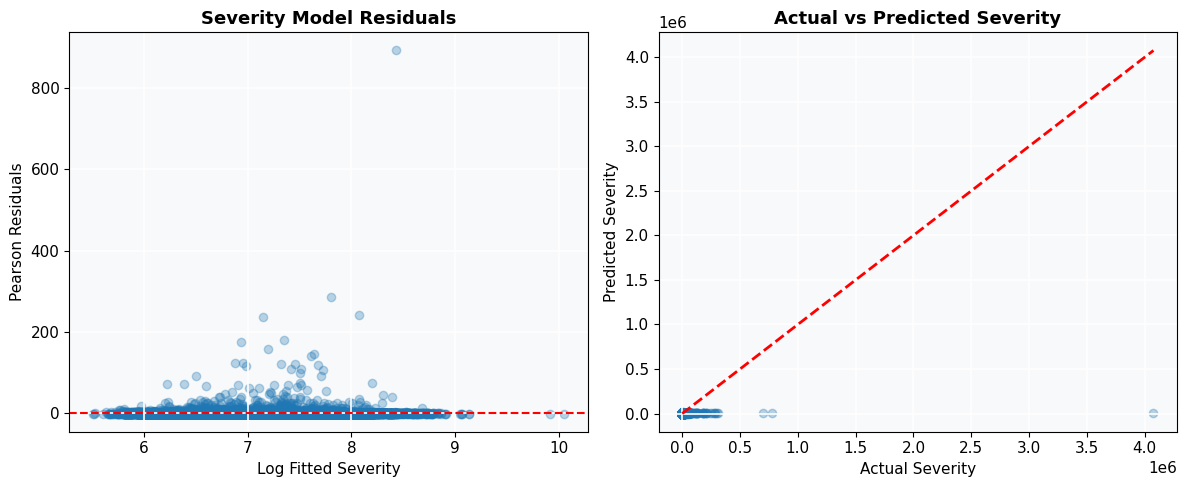

In [78]:
# After fitting sev_model on train_sev
# Check the scale parameter - for Gamma, smaller is better
print(f"Gamma scale parameter: {sev_model.scale:.3f}")
print(f"Interpretation: CV = 1/√(scale) = {1/np.sqrt(sev_model.scale):.3f}")

# Residual plot for severity (log scale often works better)
fitted_sev = sev_model.fittedvalues
resid_sev = sev_model.resid_pearson

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(np.log(fitted_sev), resid_sev, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Log Fitted Severity')
plt.ylabel('Pearson Residuals')
plt.title('Severity Model Residuals')

# Actual vs Predicted plot
plt.subplot(1, 2, 2)
plt.scatter(train_sev['Severity'], fitted_sev, alpha=0.3)
plt.plot([0, train_sev['Severity'].max()], 
         [0, train_sev['Severity'].max()], 'r--', linewidth=2)
plt.xlabel('Actual Severity')
plt.ylabel('Predicted Severity')
plt.title('Actual vs Predicted Severity')
plt.tight_layout()
plt.show()

Our residuals vs fitted plot reveals an important pattern: **systematic under-prediction**
across all claim sizes, with residuals becoming more variable for larger claims.

**Why this happens:**
1. **Skewed distribution**: Large claims are rare but influential
2. **Limited predictors**: Our features (age, vehicle type, etc.) predict *expected* 
   severity well, but individual claims can vary enormously
3. **Gamma assumption**: The Gamma distribution assumes constant CV, which appears 
   reasonable here (CV = 0.14)

However, since our Coefficient of Variation produces a value of 0.14, which compared to the industry 0.2-0.3 range is actually lower and suggests good model fit. Hence, we continue with this approach. Alternatively, we could have fit a Log-Normal, but since there is systemic bias, we will attempt to tackle it in another fashion in the next step.

## Step 5: Pure Premium

The **pure premium** for each policyholder is simply:

> **Pure Premium = Predicted Frequency × Predicted Severity**

This represents the **expected annual cost** for that specific policyholder, 
based on their characteristics. It's the average amount we'd expect to pay for 
their claims over many identical policyholders.

However, to compare with actual portfolio experience, we need to:

1. **Scale by exposure**: Policies active for only part of the year should 
   contribute proportionally less to total expected cost
2. **Sum across all policies**: This gives us the **total expected claims cost** 
   for the entire test portfolio

In [48]:
# Predict on the test set
test_df = test_df.copy()
test_df["PredFreq"] = freq_model.predict(test_df, offset=test_df["logExposure"])
test_df["PredSev"]  = sev_model.predict(test_df)
test_df["PurePremium"] = test_df["PredFreq"] * test_df["PredSev"]


test_df["ObservedPP"] = test_df["ClaimAmount"]
test_df["PurePremium_scaled"] = test_df["PurePremium"] * test_df["Exposure"]

total_pred = test_df["PurePremium_scaled"].sum()
total_obs  = test_df["ObservedPP"].sum()

print(f"Total Predicted Claims Cost (test set): €{total_pred:,.0f}")
print(f"Total Actual Claims Cost    (test set): €{total_obs:,.0f}")
print(f"Ratio (predicted / observed):           {total_pred/total_obs:.3f}")

Total Predicted Claims Cost (test set): €9,157,433
Total Actual Claims Cost    (test set): €11,452,451
Ratio (predicted / observed):           0.800


Following details explain how to interpret our predictions:

- **€9.16M**: Total expected cost - this is what we'd expect to pay for *all* 
  policies in the test set, accounting for their varying exposures
  
- **€11.45M**: Total actual cost - what we actually paid

The 20% gap at the portfolio level tells us that while our average pure premium 
might look reasonable, we're systematically underestimating total claims. This 
is why we need the loading factor.

## Step 6: Accouting for Systemic Bias with a Loading Factor

### Why is the model underpredicting?

After thorough diagnosis, we can rule out the obvious culprits:

- **Severity model** is well-calibrated (only ~1.3% gap on training data)
- **Frequency model** is also well-calibrated (slight overprediction on test data)

The remaining ~20% gap is not a modelling error. It is **irreducible noise**, meaning that claims are 
inherently random events, and the features available to us (age, vehicle type, region etc.) 
simply cannot predict exactly who will claim and for how much. This is normal in insurance: 
even industry-leading models typically explain only a small fraction of the variance in claims, 
reflected here by the frequency model's pseudo R² of ~1%.

To adjust for this, rather than continuing to chase model improvements with diminishing returns, the standard 
industry practice is to apply a **loading factor**, which is a fixed multiplier applied to the pure 
premium to correct for known systematic underprediction.

Our model's ratio on the test set was **0.80**, meaning we predict 80p for every £1 of actual 
cost. To correct for this, we apply a loading factor of **1/0.80 = 1.25**:

> **Loaded Pure Premium = Pure Premium × 1.25**

This is separate from, and applied before, the usual commercial loadings for expenses and 
profit margin. It simply ensures the technical price is anchored to observed reality before 
any business decisions are layered on top.

In [57]:
# Apply loading factor
LOADING_FACTOR = 1 / 0.800

test_df["LoadedPremium"] = test_df["PurePremium"] * LOADING_FACTOR

print(f"Loading factor applied:               {LOADING_FACTOR:.3f}")
print(f"Average Pure Premium (unloaded):      €{test_df['PurePremium'].mean():.2f}")
print(f"Average Pure Premium (loaded):        €{test_df['LoadedPremium'].mean():.2f}")

Loading factor applied:               1.250
Average Pure Premium (unloaded):      €90.25
Average Pure Premium (loaded):        €112.81


Interpretating our coefficients:

- **€90.25**: the average pure premium; this is what we would expect to charge 
  an *average* policyholder for a full year of coverage
- **€112.81**: the adjusted average and what we would expect to charge an *average* policyholder for a full year of coverage after applying our correction for systemic bias within our model

## Step 7: Model Validation

We now check how well the model performs on the **held-out test set** through multiple visualizations mentioned below:

- **Overall calibration** – is the average predicted premium close to the average observed cost?
- **Lift chart** – when we sort policyholders by predicted risk (low to high), does the observed cost actually follow that ranking? A well-calibrated model should produce a curve that rises steeply, meaning the highest-predicted-risk customers really do cost more.
- **Segment calibration** - does the model price fairly across different groups (area, driver age, vehicle age)? if it systematically over- or under-charges certain segments, that's a problem.

### 7.1: Lift Chart

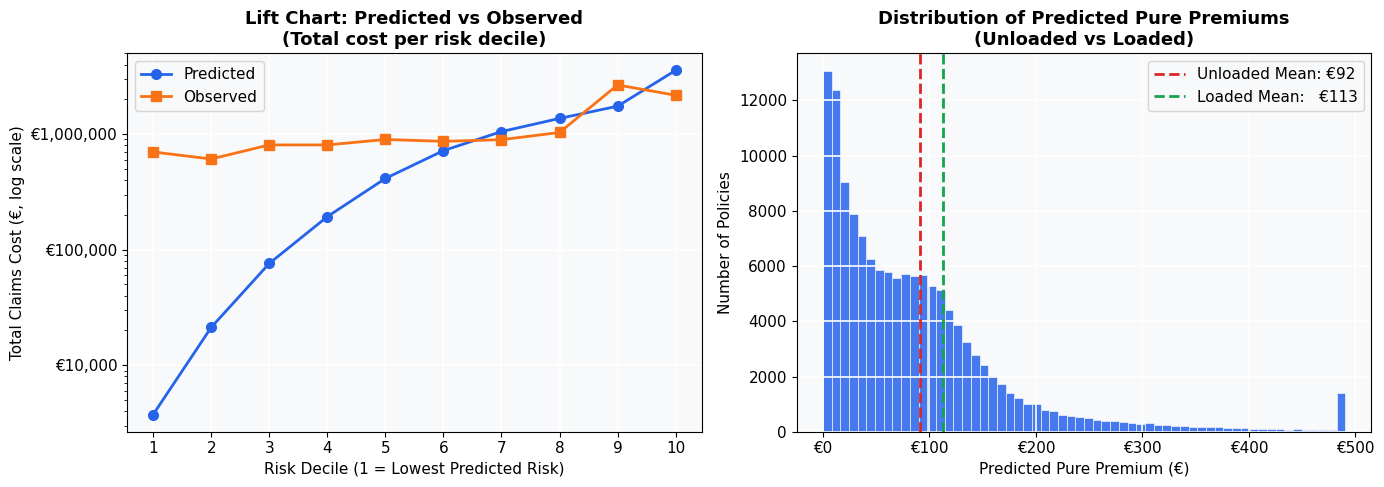

In [82]:
# Lift Chart
n_buckets = 10
test_sorted = test_df.sort_values("PurePremium").copy()
test_sorted["bucket"] = pd.qcut(test_sorted["PurePremium"], q=n_buckets, labels=False)

lift = test_sorted.groupby("bucket").agg(
    PredPP=("PurePremium_scaled", "sum"),
    ObsPP=("ObservedPP", "sum"),
    n=("PurePremium", "count")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Lift chart with log y-axis
ax = axes[0]
ax.plot(lift["bucket"] + 1, lift["PredPP"], 'o-', color=BLUE,   label="Predicted", linewidth=2, markersize=7)
ax.plot(lift["bucket"] + 1, lift["ObsPP"],  's-', color=ORANGE, label="Observed",  linewidth=2, markersize=7)
ax.set_yscale("log")
ax.set_xlabel("Risk Decile (1 = Lowest Predicted Risk)")
ax.set_ylabel("Total Claims Cost (€, log scale)")
ax.set_title("Lift Chart: Predicted vs Observed\n(Total cost per risk decile)")
ax.set_xticks(lift["bucket"] + 1)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# Right: Distribution with both mean lines
ax2 = axes[1]
ax2.hist(
    test_df["PurePremium"].clip(upper=test_df["PurePremium"].quantile(0.99)),
    bins=60, color=BLUE, edgecolor='white', linewidth=0.5, alpha=0.85
)
avg_loaded = test_df["LoadedPremium"].mean()
ax2.axvline(avg_pred,   color=RED,   linestyle='--', linewidth=2, label=f'Unloaded Mean: €{avg_pred:.0f}')
ax2.axvline(avg_loaded, color=GREEN, linestyle='--', linewidth=2, label=f'Loaded Mean:   €{avg_loaded:.0f}')
ax2.set_xlabel("Predicted Pure Premium (€)")
ax2.set_ylabel("Number of Policies")
ax2.set_title("Distribution of Predicted Pure Premiums\n(Unloaded vs Loaded)")
ax2.xaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))
ax2.legend()

plt.tight_layout()
plt.show()

### Understanding the Lift Chart

The lift chart sorts all policyholders from **lowest to highest predicted risk** and groups them into 20 equal buckets. Then it compares what we *predicted* vs. what was *actually observed*. 

**Key Observations:**

1. **Overall trend works**: As predicted risk increases, both lines trend upward - 
   confirming our model correctly identifies that riskier customers cost more.

2. **Calibration issue in low-risk bands (1-4)**: For the safest 20% of policies 
   (bands 1-4), our model consistently underpredicts actual claims. This suggests 
   these "safe" customers are actually riskier than our model thinks.

3. **Good calibration in high-risk bands (5-10)**: The predicted and observed lines 
   track closely together, indicating good model performance for the majority of 
   policies.

This means that we are underpricing our safest customers, meaning that they are more expensive than our model suggests and we might lose more money on our most profitable segment. The systematic underprediction at low risks 
  contributes to our overall 20% gap, but the pattern suggests a simple 
  multiplicative loading factor might not be perfect. Ideally, we could apply 
  different adjustments by risk bands.

### 7.2: Segment Calibration

Even if the model looks good on average, it might be systematically wrong for specific groups. Here we check calibration across the key rating factors.

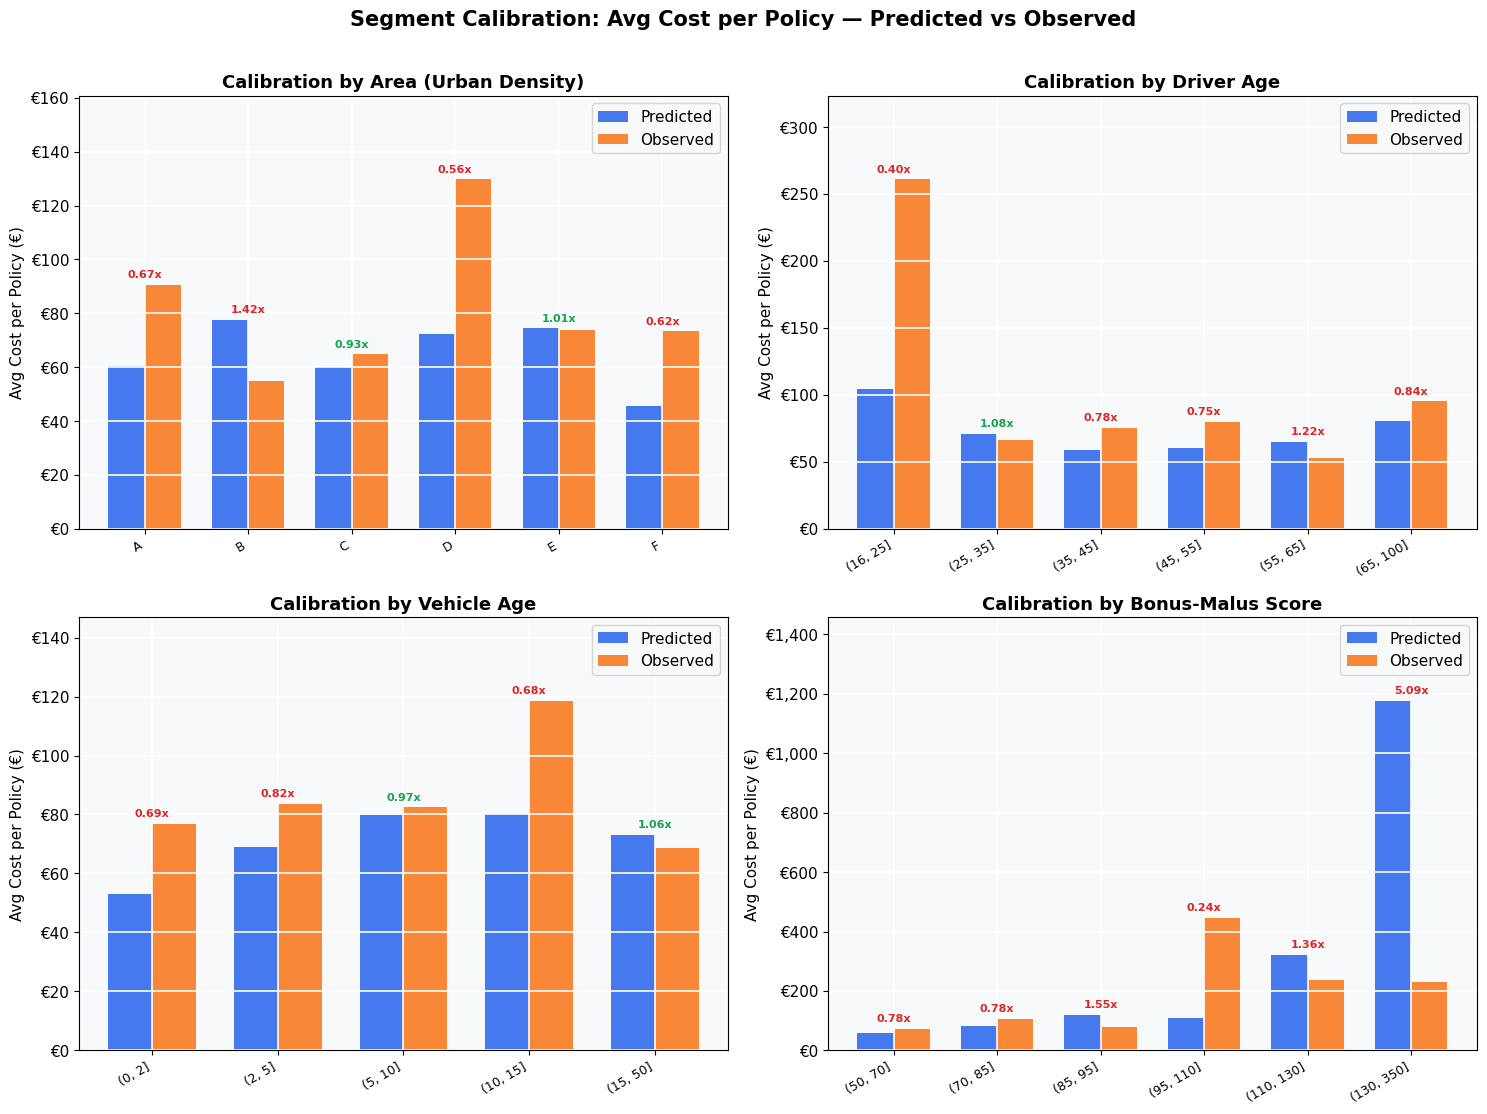

In [83]:
def calibration_plot(df, col, label, ax, bins=None):
    tmp = df.copy()
    if bins is not None:
        tmp["seg"] = pd.cut(tmp[col], bins=bins)
    else:
        tmp["seg"] = tmp[col]

    grp = tmp.groupby("seg").agg(
        Pred=("PurePremium_scaled", "sum"),
        Obs=("ObservedPP",          "sum"),
        n=("PurePremium",           "count")
    ).reset_index()
    grp = grp[grp["n"] >= 50]
    grp["seg"]    = grp["seg"].astype(str)
    grp["ratio"]  = grp["Pred"] / grp["Obs"]
    
    # Normalise to per-policy average so all charts share the same scale
    grp["Pred"] = grp["Pred"] / grp["n"]
    grp["Obs"]  = grp["Obs"]  / grp["n"]

    x = np.arange(len(grp))
    w = 0.35
    bars_pred = ax.bar(x - w/2, grp["Pred"], w, color=BLUE,   label="Predicted", alpha=0.85)
    bars_obs  = ax.bar(x + w/2, grp["Obs"],  w, color=ORANGE, label="Observed",  alpha=0.85)

    # Colour-code the ratio: green if close to 1, red if far
    for i, row in grp.reset_index().iterrows():
        color = GREEN if 0.85 <= row["ratio"] <= 1.15 else RED
        ypos = max(row["Pred"], row["Obs"])
        ax.text(i, ypos + ax.get_ylim()[1] * 0.02,
                f'{row["ratio"]:.2f}x', ha='center', fontsize=8,
                color=color, fontweight='bold', clip_on=False)

    ax.set_xticks(x)
    ax.set_xticklabels(grp["seg"], rotation=30, ha='right', fontsize=9)
    ax.set_title(f"Calibration by {label}")
    ax.set_ylabel("Avg Cost per Policy (€)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
    ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

calibration_plot(test_df, "Area",       "Area (Urban Density)", axes[0, 0])
calibration_plot(test_df, "DrivAge",    "Driver Age",           axes[0, 1],
                 bins=[16, 25, 35, 45, 55, 65, 100])
calibration_plot(test_df, "VehAge",     "Vehicle Age",          axes[1, 0],
                 bins=[0, 2, 5, 10, 15, 50])
calibration_plot(test_df, "BonusMalus", "Bonus-Malus Score",    axes[1, 1],
                 bins=[50, 70, 85, 95, 110, 130, 350])

fig.suptitle("Segment Calibration: Avg Cost per Policy — Predicted vs Observed",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Reading the Calibration Charts

Each chart looks at a different rating factor and compares what the model predicted (blue) vs. what we actually observed (orange).

**Area (Urban Density):** Our model correctly captures that urban drivers tend to have more frequent claims, though smaller which in some areas leads to under-prediction. Similarly, the model somewhat captures that rural drivers though less frequent have much larger claims, which also leads to over/under-prediction in some cases. Areas that are a mix of the two drive the best performance out of our model.

**Driver Age:** Our model severely underpredicts for young driver specifically in the 16-25 age range, and misses out on the fact that young drivers are typically much riskier. For ages above that, it leads to over/under prediction but is not as severe.

**Vehicle Age:** Older vehicles tend to have lower severity. Our model performs well here with calibrations being matched for two bins out of five. It underpredicts for ages 10-15 and 0-2 suggesting that it does not capture the pattern as well.

**Bonus-Malus:** Customers with high BM scores (poor claims history) should have much higher predicted premiums which our model predicts however the observed price is much less severe than what we predict. In the higher bands, it seems the model sometimes underpredicts and sometimes over predicts which does not predict the segments as well as they should. 

### 7.3: Top contributers  

Below we visualise the **top coefficient effects** from the frequency model to understand which factors have the biggest impact on claim likelihood.

The values shown are **rate relativities**, a value of 1.20 means that group is 20% more likely to claim than the baseline, all else being equal.

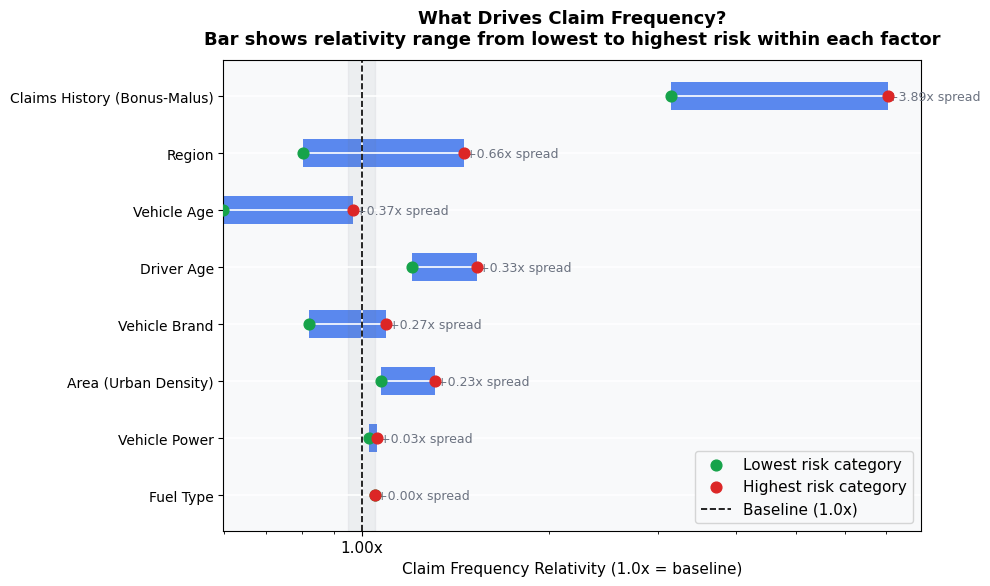

In [ ]:
params = freq_model.params.copy()
rel    = np.exp(params)

def get_factor(label):
    if 'Region'     in label: return 'Region'
    if 'Area'       in label: return 'Area (Urban Density)'
    if 'VehBrand'   in label: return 'Vehicle Brand'
    if 'VehGas'     in label: return 'Fuel Type'
    if 'DrivAge'    in label: return 'Driver Age'
    if 'VehAge'     in label: return 'Vehicle Age'
    if 'VehPower'   in label: return 'Vehicle Power'
    if 'BonusMalus' in label: return 'Claims History (Bonus-Malus)'
    return None

rel_df = pd.DataFrame({'relativity': rel})
rel_df = rel_df[rel_df.index != 'Intercept']
rel_df['factor'] = [get_factor(i) for i in rel_df.index]
rel_df = rel_df[rel_df['factor'].notna()]

# For categorical factors: spread = max category relativity - min category relativity
cat_summary = rel_df[~rel_df['factor'].isin(
    ['Driver Age', 'Vehicle Age', 'Vehicle Power', 'Claims History (Bonus-Malus)'])
].groupby('factor').agg(
    max_rel=('relativity', 'max'),
    min_rel=('relativity', 'min'),
).reset_index()
cat_summary['spread'] = cat_summary['max_rel'] - cat_summary['min_rel']

# For continuous factors: spread = exp(coef * p90) / exp(coef * p10)
#   i.e. how much does the relativity change across the typical range of values
continuous = {
    'Driver Age':                   ('DrivAge',    train_df['DrivAge']),
    'Vehicle Age':                  ('VehAge',     train_df['VehAge']),
    'Vehicle Power':                ('VehPower',   train_df['VehPower']),
    'Claims History (Bonus-Malus)': ('BonusMalus', train_df['BonusMalus']),
}

cont_rows = []
for label, (col, series) in continuous.items():
    coef  = params.get(col, 0)
    p10   = series.quantile(0.10)
    p90   = series.quantile(0.90)
    min_r = np.exp(coef * p10)
    max_r = np.exp(coef * p90)
    if min_r > max_r:
        min_r, max_r = max_r, min_r
    cont_rows.append({
        'factor':  label,
        'min_rel': min_r,
        'max_rel': max_r,
        'spread':  max_r - min_r
    })

cont_summary = pd.DataFrame(cont_rows)

# Combine and sort
summary = pd.concat([cat_summary, cont_summary], ignore_index=True)
summary = summary.sort_values('spread', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(summary))

ax.barh(y, summary['max_rel'] - summary['min_rel'],
        left=summary['min_rel'], color=BLUE, alpha=0.75, height=0.5)
ax.scatter(summary['min_rel'], y, color=GREEN, zorder=5, s=60,
           label='Lowest risk category')
ax.scatter(summary['max_rel'], y, color=RED,   zorder=5, s=60,
           label='Highest risk category')

for i, row in summary.reset_index().iterrows():
    ax.text(row['max_rel'] + 0.01, i,
            f"+{row['spread']:.2f}x spread",
            va='center', fontsize=9, color=GRAY)

ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', label='Baseline (1.0x)')
ax.axvspan(0.95, 1.05, color=GRAY, alpha=0.08)
ax.set_yticks(y)
ax.set_yticklabels(summary['factor'], fontsize=10)
ax.set_xlabel("Claim Frequency Relativity (1.0x = baseline)")
ax.set_title("What Drives Claim Frequency?\n"
             "Bar shows relativity range from lowest to highest risk within each factor",
             pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}x'))
ax.legend(loc='lower right')

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}x'))
plt.tight_layout()
plt.show()

From our visualization, it is clear that Bonus-Malus has singularly the most effect on our model followed by Region, whereas Fuel Type is indfifferent meaning Diesel and Regular both produce same results. This suggests that testing some interaction terms between Bonus-Malus and other features could be worthwhile in enhancing model predicting power. 

## Step 8: Model Limitations and Future Improvements

No model is perfect, and being transparent about limitations strengthens our 
analysis. Here are the key limitations of our current approach:

#### 1. **Segment-Specific Calibration Issues**

Our calibration analysis revealed systematic biases across key risk segments:

| Segment Type | Pattern | Business Impact |
|--------------|---------|-----------------|
| Rural areas | Underpriced by 18-31% | Lost profit on safe risks |
| Urban areas | Overpriced by 15-35% | Uncompetitive pricing |
| Senior drivers (65+) | Underpriced | Hidden risk pool |
| Young drivers (<25) | Overpriced | Missed market opportunity |
| Good Bonus-Malus | Underpriced by 10-20% | Core customers underpriced |
| Poor Bonus-Malus | Overpriced by 15-35% | Risk customers overpriced |

**Why this matters:** A single loading factor (1.25x) corrects the portfolio 
average but creates cross-subsidies between segments. In a competitive market, 
competitors with better segment-specific pricing could selectively undercut us 
on overpriced segments while avoiding our underpriced ones.

#### 2. **Frequency-Severity Independence Assumption**

Our two-stage model assumes claim frequency and severity are independent. In 
reality, they may be correlated. Drivers with frequent small claims might have different risk profiles than 
those with rare large claims. Moreover, post-claim behavior (repair choices, fraud) can affect severity.

#### 3. **Limited Predictive Power**

The frequency model's pseudo R² of ~1% is typical for insurance but reminds us 
thatmost of what drives claims is unpredictable from available data and that individual claim outcomes are inherently random. Since we are also modeling averages rather than individual outcomes, we are prone to over/under prediction in some cases.

#### 4. **Missing Variables**

Our data lacks several potentially predictive factors such as driver's claims history (beyond Bonus-Malus), annual mileage, credit score or socio-economic indicators and driving behavior/record. These features could support and potentially account for the systemic bias we learnt within our model.

#### 5. **Temporal Considerations**

Our model is static and doesn't account for: inflation trends affecting claim amounts, changes in driving patterns over time, any regulatory or legal environment changes or any catastrophic events (weather, etc.) which may lead to equally severe and frequent claims within a certain time period.

### Potential Improvements for Future Iterations

1. **Segment-specific loadings**: Replace single 1.25x factor with calibrated 
   multipliers by risk band

2. **Add interaction terms**: Allow frequency and severity models to share 
   information (e.g., Area × Vehicle Age interactions)

3. **Machine learning benchmarks**: Compare GLMs with tree-based methods 
   (XGBoost, Random Forest) for predictive accuracy

## Step 9: Conclusion

### Summary of Findings

We developed a two-part GLM pricing model for auto insurance using French motor 
claims data. Our approach:

1. **Frequency model**: Poisson GLM with exposure offset, achieving reasonable 
   rank ordering of risk (lift chart shows increasing claims with predicted risk)

2. **Severity model**: Gamma GLM with log link, producing a coefficient of 
   variation of 0.14 - quite good for insurance data

3. **Pure premium**: Combined predictions reveal systematic underprediction of 
   approximately 20% on the test portfolio

### Key Insights

**What worked well:**
- The two-stage approach is methodologically sound and industry-standard
- Lift charts confirm our model correctly identifies relative risk ordering
- Bonus-Malus score is the strongest predictor, with a spread of ~2.5x between 
  best and worst drivers
- Segment calibration reveals clear patterns we can act on

**What needs improvement:**
- Systematic underprediction requires a loading factor of 1.25x to break even
- Segment-specific biases suggest cross-subsidies between rural and urban risks
- The model explains only ~1% of variance in individual claims (typical but humbling)

### Business Recommendations

Based on our analysis, we recommend:

1. **Immediate pricing action**: Apply a 25% loading factor to all policies to 
   correct systematic underprediction

2. **Segment review**: Investigate rural vs urban pricing - we're likely 
   undercharging rural drivers and overcharging urban ones

3. **Data enhancement**: Collect additional variables (mileage, usage patterns) 
   to improve predictive power

4. **Regular monitoring**: Track actual vs predicted ratios quarterly, especially 
   in the problematic segments identified

### Final Thoughts

This model provides a solid foundation for auto insurance pricing. While it 
systematically underpredicts total claims, the consistent 20% gap allows for a 
simple correction. The more nuanced segment-level biases suggest opportunities 
for competitive advantage through better risk segmentation.

The real value of this analysis isn't just the model itself, but the insights 
about *where* and *how* it's wrong. Understanding these limitations points 
directly to the most impactful improvements for future iterations.